# NVIDIA ALCHEMI Batched Molecular Dynamics (BMD): From Unit Cells to Thermodynamic Metrics

This playbook demonstrates an end-to-end materials science workflow using NVIDIA ALCHEMI's
GPU-accelerated **Batched Molecular Dynamics (BMD)** and **Batch Geometry Relaxation (BGR)**
NIM-style microservices — from crystallographic unit cell construction through thermodynamic
property extraction.

The UDC (Universal Display Corporation) track at the end shows how this same infrastructure
can predict thermal processing stability for OLED materials discovery at 10,000× DFT speedup.

## What You Will Learn

1. **Connect** to the ALCHEMI BMD/BGR REST endpoints and verify availability
2. **Build** crystalline supercells programmatically with pymatgen
3. **Run NVT/NPT** molecular dynamics via single API calls
4. **Extract properties**: density, RDF, MSD, diffusion coefficient, thermal expansion
5. **Batch** simulations for temperature sweeps
6. **UDC workflow**: conformer generation → batched MD → stability scoring
7. **Switch MLIPs** with a one-line parameter change

> **Prerequisites**
>
> - NVIDIA ALCHEMI BMD NIM running on `localhost:8000` **or** cached responses in `cached_responses/`
> - NVIDIA ALCHEMI BGR NIM running on `localhost:8890` **or** cached responses in `cached_responses/`
> - Python ≥ 3.11 with packages from `environment.yml`
> - ~5 min for FAST_DEMO, ~30 min for full production runs

---
## 1. Environment Setup & Control Panel

In [1]:
# --- Imports and version check ---
import sys, os, json, warnings
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore", category=DeprecationWarning)

_missing = []
for _pkg in ["ase", "pymatgen", "pydantic", "requests", "rdkit"]:
    try:
        __import__(_pkg)
    except ImportError:
        _missing.append(_pkg)

# OVITO is optional for rendering
OVITO_AVAILABLE = True
try:
    import ovito
except ImportError:
    OVITO_AVAILABLE = False
    print("ovito not installed — structure rendering will be skipped.")

if _missing:
    print(f"Missing packages: {_missing}")
    print("Install with: pip install " + " ".join(_missing))
else:
    from importlib.metadata import version as _pkg_version
    print("All required packages available.")
    print(f"  ASE {_pkg_version('ase')}")
    print(f"  pymatgen {_pkg_version('pymatgen')}")
    print(f"  pydantic {_pkg_version('pydantic')}")

All required packages available.
  ASE 3.27.0
  pymatgen 2025.10.7
  pydantic 2.12.5


In [2]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║                      CONTROL PANEL                             ║
# ║  Adjust these parameters to control simulation behaviour.      ║
# ╚══════════════════════════════════════════════════════════════════╝

# --- Demo mode ---
FAST_DEMO = True                  # True: short sims + cached responses

# --- Endpoint ---
SERVER_URL = "http://localhost:8000"
BGR_SERVER_URL = "http://localhost:8890"   # BGR NIM endpoint

# --- MD parameters ---
T_KELVIN     = 300.0              # Target temperature (K)
P_KBAR       = 0.0                # External pressure (kBar) — 0 = ambient
DT_FS        = 1.0                # Integration timestep (fs)
FRICTION     = 1.0                # Langevin friction (ps^-1)
SEED         = 42                 # RNG seed for reproducibility

# --- Simulation lengths (gated by FAST_DEMO) ---
NSTEPS_EQUIL = 200 if FAST_DEMO else 5000
NSTEPS_PROD  = 500 if FAST_DEMO else 10000
SAVE_INTERVAL = 10 if FAST_DEMO else 100

# --- Structure ---
SUPERCELL_DIMS = (2, 2, 2) if FAST_DEMO else (3, 3, 3)

# --- Temperature sweep ---
TEMPERATURES = [200, 300, 400] if FAST_DEMO else [200, 250, 300, 350, 400, 450, 500]

# --- Paths ---
CACHE_DIR      = "cached_responses"
OUTPUT_DIR     = "outputs"
STRUCTURE_DIR  = "structures"

print(f"FAST_DEMO = {FAST_DEMO}")
print(f"Equilibration: {NSTEPS_EQUIL} steps | Production: {NSTEPS_PROD} steps")
print(f"Supercell: {SUPERCELL_DIMS} | Temperatures: {TEMPERATURES}")

FAST_DEMO = True
Equilibration: 200 steps | Production: 500 steps
Supercell: (2, 2, 2) | Temperatures: [200, 300, 400]


In [3]:
# --- Helper imports and directory setup ---
sys.path.insert(0, ".")
from helpers import (
    MDAtomicData, MDConfig, MDRequest, MDSnapshot, MDReply,
    AtomicData, BGRRequest, BGRReply,
    KE_CONV, BOLTZ_EV_K, P_CONV,
    read_structure, ase_to_atomic_data, atomic_data_to_ase,
    check_endpoint, run_md, run_bgr,
    run_md_or_load_cache, run_bgr_or_load_cache,
    extract_thermo_timeseries, trajectory_to_ase_list,
    compute_rdf, compute_msd, estimate_diffusion_coefficient,
    compute_density, thermal_expansion_proxy, pick_production_window,
    save_cache, load_cache, cache_exists,
)
from helpers.models import ase_to_md_atomic_data

if OVITO_AVAILABLE:
    from helpers import render_structure_ovito, display_inline, structure_summary_table
else:
    from helpers import structure_summary_table

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)
print("Helpers loaded. Output directories ready.")

Helpers loaded. Output directories ready.


---
## 2. Endpoint Connectivity & API Hello World

Before running simulations we verify the BMD NIM is reachable. If it isn't, every
subsequent cell will fall back to cached responses (when `FAST_DEMO = True`).

In [4]:
ENDPOINT_LIVE = check_endpoint(SERVER_URL)
if ENDPOINT_LIVE:
    print(f"Endpoint is LIVE at {SERVER_URL}")
else:
    print(f"Endpoint NOT reachable at {SERVER_URL} — will use cached responses.")
BGR_ENDPOINT_LIVE = check_endpoint(BGR_SERVER_URL)
if BGR_ENDPOINT_LIVE:
    print(f"BGR endpoint is LIVE at {BGR_SERVER_URL}")
else:
    print(f"BGR endpoint NOT reachable at {BGR_SERVER_URL} — will use cached responses.")


Endpoint is LIVE at http://localhost:8000


### Request / Response Schema

| Field | Type | Description |
|-------|------|-------------|
| `atoms.coord` | `List[float]` | Flattened xyz coordinates (Å) |
| `atoms.numbers` | `List[int]` | Atomic numbers |
| `atoms.cell` | `List[float]` | 3×3 flattened lattice vectors (Å) |
| `atoms.pbc` | `List[bool]` | Periodic boundary conditions |
| `atoms.velocity` | `List[float]` | Flattened velocities (Å/fs) |
| `config.temperature` | `float` | Target temperature (K) |
| `config.dt` | `float` | Timestep (fs) |
| `config.nvt` / `config.npt` | `bool` | Thermostat / barostat toggles |
| `config.md_time_max` | `float` | Simulation end time (ps) |
| `config.save_interval` | `int` | Frames saved every N steps |
| **Response** | | |
| `trajectory[].energy` | `float` | Potential energy (eV) |
| `trajectory[].coord` | `List[float]` | Updated coordinates |
| `trajectory[].velocity` | `List[float]` | Updated velocities |
| `trajectory[].cell` | `List[float]` | Updated cell (NPT) |
| `trajectory[].stress` | `List[float]` | Virial stress tensor (eV/Å³) |

In [5]:
# --- API Hello World: tiny H2 MD ---
h2_atoms = MDAtomicData(
    coord=[0.0, 0.0, 0.0, 0.0, 0.0, 0.74],
    numbers=[1, 1],
    cell=[10.0, 0.0, 0.0, 0.0, 10.0, 0.0, 0.0, 0.0, 10.0],
    pbc=[True, True, True],
)
h2_config = MDConfig(
    temperature=300.0,
    dt=1.0,
    nvt=True,
    npt=False,
    md_time_max=0.01,   # 10 fs
    save_interval=1,
)

h2_reply = run_md_or_load_cache(
    h2_atoms, h2_config, SERVER_URL, CACHE_DIR, "h2_hello_world", ENDPOINT_LIVE
)

print(f"Status      : {h2_reply.status}")
print(f"Frames      : {len(h2_reply.trajectory)}")
print(f"Final energy: {h2_reply.trajectory[-1].energy:.6f} eV")

  Loading cached response: h2_hello_world
Status      : Success
Frames      : 11
Final energy: -6.511127 eV


In [6]:
# --- Pretty-print request and first response snapshot ---
request_dict = MDRequest(atoms=h2_atoms, config=h2_config).model_dump()
print("=== REQUEST (first 40 lines) ===")
print(json.dumps(request_dict, indent=2)[:2000])

print("\n=== FIRST RESPONSE SNAPSHOT ===")
snap0 = h2_reply.trajectory[0].model_dump()
print(json.dumps(snap0, indent=2)[:1500])

=== REQUEST (first 40 lines) ===
{
  "atoms": {
    "coord": [
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.74
    ],
    "numbers": [
      1,
      1
    ],
    "charge": 0,
    "mult": 1,
    "cell": [
      10.0,
      0.0,
      0.0,
      0.0,
      10.0,
      0.0,
      0.0,
      0.0,
      10.0
    ],
    "pbc": [
      true,
      true,
      true
    ],
    "structure_id": null,
    "mass": null,
    "velocity": null
  },
  "config": {
    "temperature": 300.0,
    "dt": 1.0,
    "nvt": true,
    "friction": 1.0,
    "npt": false,
    "barostat_prob_shear": 0.5,
    "barostat_shear_max": 0.001,
    "barostat_diag_max": 0.003,
    "barostat_log_scale_max": 0.005,
    "pressure": 0.0,
    "barostat_every": 25,
    "barostat_anisotropic": false,
    "istep": 0,
    "md_time": 0.0,
    "md_time_max": 0.01,
    "save_interval": 1,
    "efield": [
      0.0,
      0.0,
      0.0
    ]
  },
  "info": null
}

=== FIRST RESPONSE SNAPSHOT ===
{
  "coord": [
    0.0,

### Common Failure Modes

| Error | Cause | Fix |
|-------|-------|-----|
| `ConnectionError` | NIM not running | Start container on port 8000 |
| `422 Unprocessable` | Malformed request | Check `coord` length = 3 × N |
| `Simulation diverged` | Timestep too large / bad geometry | Reduce `dt`, relax first |
| `Timeout` | Long simulation | Increase timeout or chunk `md_time_max` |

---
## 3. Unit Cell → Supercell → MD-Ready Structure

We build **NaCl** (rock-salt, Fm-3m) as a well-characterised crystalline benchmark:
experimental density ≈ 2.165 g/cm³, first RDF peak ≈ 2.82 Å.

In [7]:
# --- Build NaCl unit cell with pymatgen ---
from pymatgen.core import Lattice, Structure
from pymatgen.io.ase import AseAtomsAdaptor

nacl_struct = Structure.from_spacegroup(
    "Fm-3m",
    Lattice.cubic(5.64),
    ["Na", "Cl"],
    [[0, 0, 0], [0.5, 0.5, 0.5]],
)
print(f"Unit cell: {nacl_struct.composition} — {len(nacl_struct)} atoms")
print(f"Lattice parameter: a = {nacl_struct.lattice.a:.3f} Å")

Unit cell: Na4 Cl4 — 8 atoms
Lattice parameter: a = 5.640 Å


In [8]:
# --- Make supercell and convert to ASE ---
nacl_super = nacl_struct.copy()
nacl_super.make_supercell(SUPERCELL_DIMS)
print(f"Supercell: {SUPERCELL_DIMS} → {len(nacl_super)} atoms")

adaptor = AseAtomsAdaptor()
nacl_ase = adaptor.get_atoms(nacl_super)
print(f"ASE Atoms: {nacl_ase.get_chemical_formula()} | Volume: {nacl_ase.get_volume():.1f} Å³")

Supercell: (2, 2, 2) → 64 atoms
ASE Atoms: Cl32Na32 | Volume: 1435.2 Å³


In [9]:
# --- Convert to MDAtomicData and save CIF ---
nacl_md_atoms = ase_to_md_atomic_data(nacl_ase)
print(f"MDAtomicData: {len(nacl_md_atoms.numbers)} atoms")
print(f"  coord length: {len(nacl_md_atoms.coord)} (= 3 × {len(nacl_md_atoms.numbers)})")
print(f"  PBC: {nacl_md_atoms.pbc}")

import ase.io
cif_path = os.path.join(OUTPUT_DIR, "nacl_supercell.cif")
ase.io.write(cif_path, nacl_ase)
print(f"  Saved: {cif_path}")

MDAtomicData: 64 atoms
  coord length: 192 (= 3 × 64)
  PBC: [True, True, True]
  Saved: outputs/nacl_supercell.cif


In [10]:
# --- Optional: BGR geometry relaxation ---
try:
    nacl_bgr_atom = ase_to_atomic_data(nacl_ase, _id="nacl_supercell")
    bgr_reply = run_bgr_or_load_cache(
        [nacl_bgr_atom], BGR_SERVER_URL, CACHE_DIR, "nacl_bgr_relax",
        BGR_ENDPOINT_LIVE, cellopt=True
    )
    relaxed = atomic_data_to_ase(bgr_reply.atoms[0])
    print(f"BGR converged: {bgr_reply.atoms[0].converged}")
    print(f"Relaxed energy: {bgr_reply.atoms[0].energy:.4f} eV")
    # Use relaxed structure for MD
    nacl_ase = relaxed
    nacl_md_atoms = ase_to_md_atomic_data(nacl_ase)
except Exception as e:
    print(f"BGR skipped: {e}")
    print("Proceeding with unrelaxed supercell.")

  Running live BGR optimisation: nacl_bgr_relax ...
BGR skipped: 422 Client Error: Unprocessable Entity for url: http://localhost:8000/infer
Proceeding with unrelaxed supercell.


,Formula,Atoms,a (A),b (A),c (A),Volume (A^3),Density (g/cm^3)
0,Cl32 Na32,64,11.28,11.28,11.28,1435.25,2.164


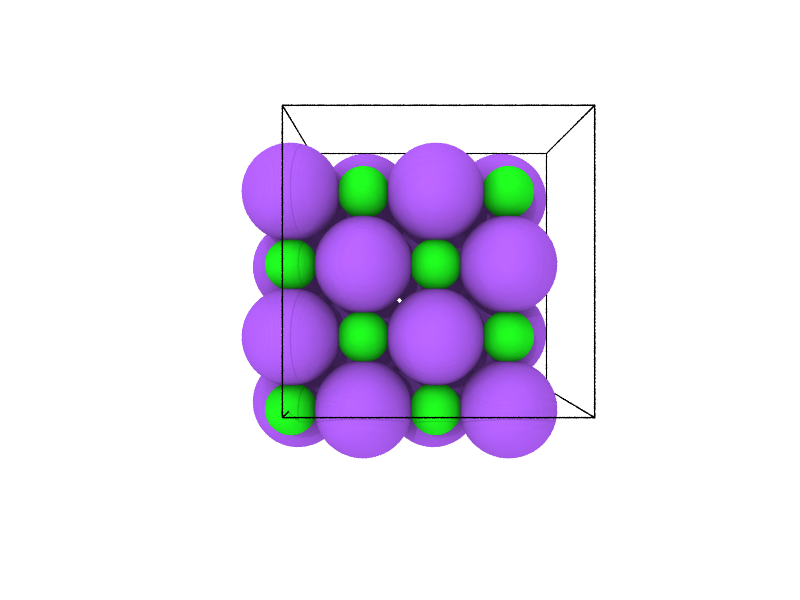

In [11]:
# --- OVITO render + structure summary ---
summary_df = structure_summary_table(nacl_ase)
display(summary_df)

if OVITO_AVAILABLE:
    img_path = render_structure_ovito(nacl_ase, os.path.join(OUTPUT_DIR, "nacl_render.png"))
    display_inline(img_path)
else:
    print("(OVITO not available — skipping 3D render)")

---
## 4. Run MD — NVT Equilibration → NPT Production

**Workflow:**
1. **NVT equilibration** — Langevin thermostat, fixed cell → thermalise velocities
2. **NPT production** — Langevin thermostat + MC barostat → sample equilibrium ensemble

The MLIP model is selected server-side. Switching models (e.g. MACE-MP-0 → SevenNet)
requires only restarting the NIM with a different `--model` flag — no client code changes.

In [12]:
# --- NVT Equilibration ---
equil_time_ps = NSTEPS_EQUIL * DT_FS / 1000.0

nvt_config = MDConfig(
    temperature=T_KELVIN,
    dt=DT_FS,
    nvt=True,
    npt=False,
    friction=FRICTION,
    pressure=P_KBAR,
    md_time_max=equil_time_ps,
    save_interval=SAVE_INTERVAL,
)

nvt_reply = run_md_or_load_cache(
    nacl_md_atoms, nvt_config, SERVER_URL, CACHE_DIR,
    "nacl_nvt_equil", ENDPOINT_LIVE
)
print(f"NVT status: {nvt_reply.status} | Frames: {len(nvt_reply.trajectory)}")
print(f"Final E_pot: {nvt_reply.trajectory[-1].energy:.4f} eV")

  Loading cached response: nacl_nvt_equil
NVT status: Success | Frames: 21
Final E_pot: -214.9355 eV


In [13]:
# --- Extract final NVT snapshot → seed NPT ---
last_snap = nvt_reply.trajectory[-1]
npt_atoms = MDAtomicData(
    coord=last_snap.coord,
    numbers=nacl_md_atoms.numbers,
    charge=nacl_md_atoms.charge,
    mult=nacl_md_atoms.mult,
    cell=last_snap.cell if last_snap.cell else nacl_md_atoms.cell,
    pbc=nacl_md_atoms.pbc,
    velocity=last_snap.velocity,
)
print(f"NPT seed: {len(npt_atoms.numbers)} atoms with velocities from NVT")

NPT seed: 64 atoms with velocities from NVT


In [14]:
# --- NPT Production ---
prod_time_ps = NSTEPS_PROD * DT_FS / 1000.0

npt_config = MDConfig(
    temperature=T_KELVIN,
    dt=DT_FS,
    nvt=True,
    npt=True,
    friction=FRICTION,
    pressure=P_KBAR,
    md_time_max=prod_time_ps,
    save_interval=SAVE_INTERVAL,
)

npt_reply = run_md_or_load_cache(
    npt_atoms, npt_config, SERVER_URL, CACHE_DIR,
    "nacl_npt_prod", ENDPOINT_LIVE
)
print(f"NPT status: {npt_reply.status} | Frames: {len(npt_reply.trajectory)}")
print(f"Final E_pot: {npt_reply.trajectory[-1].energy:.4f} eV")

  Loading cached response: nacl_npt_prod
NPT status: Success | Frames: 51
Final E_pot: -214.9893 eV


> **Batching tip**: For long simulations, chunk `md_time_max` into segments and
> chain requests by feeding the final snapshot of run *N* as the initial state of
> run *N+1*. For parameter sweeps (e.g. multiple temperatures), submit requests
> concurrently with `asyncio` / `aiohttp`.

---
## 5. Thermodynamic Property Extraction

From the NPT trajectory we extract:
- **Temperature**, **pressure**, **energy**, **volume** time series
- **Equilibrium density** (from ⟨V⟩)
- **Radial distribution function** g(r) — Na-Cl and Na-Na
- **Mean-squared displacement** and diffusion coefficient
- **Thermal expansion coefficient** α_V from a temperature sweep

In [15]:
# --- Extract thermo timeseries ---
thermo = extract_thermo_timeseries(npt_atoms, npt_reply.trajectory)
print(f"Extracted {len(thermo['time_ps'])} frames")
print(f"T range: {thermo['temperature_K'].min():.0f} – {thermo['temperature_K'].max():.0f} K")
print(f"V range: {thermo['volume_A3'].min():.1f} – {thermo['volume_A3'].max():.1f} Å³")

Extracted 51 frames
T range: 170 – 248 K
V range: 1435.2 – 1527.3 Å³


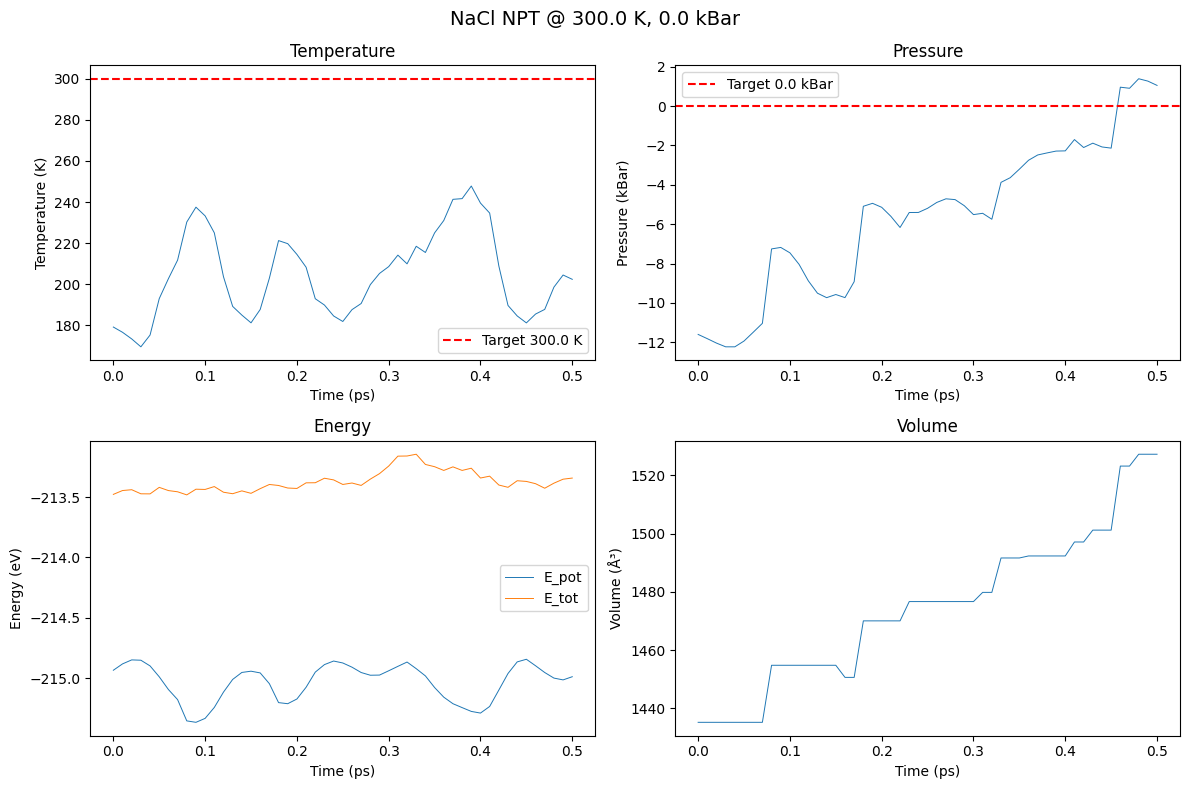

In [16]:
# --- 2×2 thermo plot ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

t = thermo["time_ps"]

axes[0, 0].plot(t, thermo["temperature_K"], lw=0.7)
axes[0, 0].axhline(T_KELVIN, color="r", ls="--", label=f"Target {T_KELVIN} K")
axes[0, 0].set(xlabel="Time (ps)", ylabel="Temperature (K)", title="Temperature")
axes[0, 0].legend()

axes[0, 1].plot(t, thermo["pressure_kbar"], lw=0.7)
axes[0, 1].axhline(P_KBAR, color="r", ls="--", label=f"Target {P_KBAR} kBar")
axes[0, 1].set(xlabel="Time (ps)", ylabel="Pressure (kBar)", title="Pressure")
axes[0, 1].legend()

axes[1, 0].plot(t, thermo["e_pot_eV"], lw=0.7, label="E_pot")
axes[1, 0].plot(t, thermo["e_tot_eV"], lw=0.7, label="E_tot")
axes[1, 0].set(xlabel="Time (ps)", ylabel="Energy (eV)", title="Energy")
axes[1, 0].legend()

axes[1, 1].plot(t, thermo["volume_A3"], lw=0.7)
axes[1, 1].set(xlabel="Time (ps)", ylabel="Volume (Å³)", title="Volume")

fig.suptitle(f"NaCl NPT @ {T_KELVIN} K, {P_KBAR} kBar", fontsize=14)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "nacl_thermo.png"), dpi=150)
plt.show()

In [17]:
# --- Equilibrium density ---
start_idx, end_idx = pick_production_window(thermo, discard_fraction=0.3)
prod_volumes = thermo["volume_A3"][start_idx:end_idx]

density = compute_density(npt_atoms, prod_volumes)
print(f"Production window: frames {start_idx}–{end_idx}")
print(f"Mean volume: {prod_volumes.mean():.2f} ± {prod_volumes.std():.2f} Å³")
print(f"Computed density: {density:.3f} g/cm³")
print(f"Experimental NaCl: ~2.165 g/cm³")
print(f"Deviation: {abs(density - 2.165)/2.165*100:.1f}%")

Production window: frames 15–51
Mean volume: 1487.31 ± 20.12 Å³
Computed density: 2.088 g/cm³
Experimental NaCl: ~2.165 g/cm³
Deviation: 3.6%


In [ ]:
# --- Radial Distribution Function ---
frames = trajectory_to_ase_list(npt_atoms, npt_reply.trajectory)

r_nacl, g_nacl = compute_rdf(frames, species_pair=(11, 17), r_max=8.0, start_frame=start_idx)
r_nana, g_nana = compute_rdf(frames, species_pair=(11, 11), r_max=8.0, start_frame=start_idx)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(r_nacl, g_nacl, label="Na–Cl", lw=1.5)
ax.plot(r_nana, g_nana, label="Na–Na", lw=1.5)
ax.axvline(2.82, color="gray", ls=":", alpha=0.6, label="Expt Na–Cl 1st peak")
ax.set(xlabel="r (Å)", ylabel="g(r)", title="Radial Distribution Function — NaCl")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "nacl_rdf.png"), dpi=150)
plt.show()

In [ ]:
# --- MSD and diffusion coefficient ---
t_na, msd_na = compute_msd(frames, species=11, start_frame=start_idx)
t_cl, msd_cl = compute_msd(frames, species=17, start_frame=start_idx)

D_na = estimate_diffusion_coefficient(t_na, msd_na)
D_cl = estimate_diffusion_coefficient(t_cl, msd_cl)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(t_na, msd_na, label=f"Na  (D ≈ {D_na:.3e} Å²/ps)", lw=1.5)
ax.plot(t_cl, msd_cl, label=f"Cl  (D ≈ {D_cl:.3e} Å²/ps)", lw=1.5)
ax.set(xlabel="Time (ps)", ylabel="MSD (Å²)", title="Mean Squared Displacement — NaCl")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "nacl_msd.png"), dpi=150)
plt.show()

### Thermal Expansion

The volumetric thermal expansion coefficient is defined as:

$$\alpha_V = \frac{1}{V}\left(\frac{\partial V}{\partial T}\right)_P = -\frac{1}{\rho}\left(\frac{\partial \rho}{\partial T}\right)_P$$

We estimate $\alpha_V$ by running NPT at several temperatures and fitting
$\rho(T)$.  Literature value for NaCl: $\alpha_V \approx 1.2 \times 10^{-4}\,\mathrm{K}^{-1}$.

In [ ]:
# --- Temperature sweep: NPT at multiple T ---
sweep_densities = []
sweep_temps = []

for T in TEMPERATURES:
    label = f"nacl_npt_T{T}"
    print(f"\n--- T = {T} K ---")

    # NVT equilibration at this T
    nvt_cfg = MDConfig(
        temperature=float(T), dt=DT_FS, nvt=True, npt=False,
        friction=FRICTION, md_time_max=equil_time_ps, save_interval=SAVE_INTERVAL,
    )
    nvt_r = run_md_or_load_cache(
        nacl_md_atoms, nvt_cfg, SERVER_URL, CACHE_DIR,
        f"nacl_nvt_T{T}", ENDPOINT_LIVE
    )

    # Seed NPT from NVT final snapshot
    s = nvt_r.trajectory[-1]
    seed = MDAtomicData(
        coord=s.coord, numbers=nacl_md_atoms.numbers,
        charge=nacl_md_atoms.charge, mult=nacl_md_atoms.mult,
        cell=s.cell if s.cell else nacl_md_atoms.cell,
        pbc=nacl_md_atoms.pbc, velocity=s.velocity,
    )
    npt_cfg = MDConfig(
        temperature=float(T), dt=DT_FS, nvt=True, npt=True,
        friction=FRICTION, pressure=P_KBAR,
        md_time_max=prod_time_ps, save_interval=SAVE_INTERVAL,
    )
    npt_r = run_md_or_load_cache(
        seed, npt_cfg, SERVER_URL, CACHE_DIR, label, ENDPOINT_LIVE
    )

    # Extract density
    th = extract_thermo_timeseries(seed, npt_r.trajectory)
    s0, s1 = pick_production_window(th)
    rho = compute_density(seed, th["volume_A3"][s0:s1])
    sweep_densities.append(rho)
    sweep_temps.append(T)
    print(f"  density = {rho:.4f} g/cm³")

sweep_temps = np.array(sweep_temps, dtype=float)
sweep_densities = np.array(sweep_densities)

In [ ]:
# --- Plot density vs temperature and estimate alpha_V ---
alpha_v = thermal_expansion_proxy(sweep_temps, sweep_densities)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sweep_temps, sweep_densities, "o-", lw=1.5, markersize=8)
ax.set(xlabel="Temperature (K)", ylabel="Density (g/cm³)",
       title="NaCl Density vs Temperature (NPT)")

# Linear fit overlay
fit = np.polyfit(sweep_temps, sweep_densities, 1)
ax.plot(sweep_temps, np.polyval(fit, sweep_temps), "r--", lw=1,
        label=f"Linear fit: α_V ≈ {alpha_v:.2e} K⁻¹")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "nacl_thermal_expansion.png"), dpi=150)
plt.show()

print(f"Estimated α_V = {alpha_v:.2e} K⁻¹")
print(f"Literature NaCl: ~1.2e-4 K⁻¹")

---
## 6. UDC-Inspired Conformer Stability Workflow

Universal Display Corporation (UDC) used ALCHEMI to screen OLED materials for
thermal processing stability at 10,000× DFT speedup. The workflow:

1. **Generate conformers** for a candidate molecule
2. **Build simulation cells** (non-periodic, gas-phase)
3. **Batched NVT MD** at elevated temperature
4. **Score stability** from energy statistics (lower variance → more stable)

We demonstrate with **naphthalene (C₁₀H₈)** — the simplest polycyclic aromatic
and structural analogue to OLED emitter cores.

In [ ]:
# --- Generate conformers from naphthalene XYZ ---
# Base conformer from file
naph_base = ase.io.read(os.path.join(STRUCTURE_DIR, "naphthalene.xyz"))
print(f"Naphthalene: {naph_base.get_chemical_formula()} — {len(naph_base)} atoms")

# Generate perturbed conformers by adding small random displacements
np.random.seed(SEED)
conformers = [naph_base.copy()]
for i in range(2):
    conf = naph_base.copy()
    noise = np.random.normal(0, 0.05, conf.positions.shape)
    conf.positions += noise
    conformers.append(conf)
    print(f"  Conformer {i+1}: perturbed by ±0.05 Å")

print(f"Total conformers: {len(conformers)}")

In [ ]:
# --- Convert conformers to MDAtomicData (large periodic box for gas-phase) ---
BOX_SIZE = 50.0  # Large box to simulate gas-phase (no self-interaction)
large_cell = [BOX_SIZE, 0.0, 0.0, 0.0, BOX_SIZE, 0.0, 0.0, 0.0, BOX_SIZE]

conformer_atoms_list = []
for i, conf in enumerate(conformers):
    # Centre molecule in the box
    centroid = conf.positions.mean(axis=0)
    centred_pos = conf.positions - centroid + BOX_SIZE / 2.0
    md_data = MDAtomicData(
        coord=centred_pos.flatten().tolist(),
        numbers=conf.numbers.tolist(),
        cell=large_cell,
        pbc=[True, True, True],
        structure_id=f"naph_conf_{i}",
    )
    conformer_atoms_list.append(md_data)
    print(f"Conformer {i}: {len(md_data.numbers)} atoms, {BOX_SIZE} Å periodic box")

In [ ]:
# --- Batched NVT MD at elevated T ---
T_UDC = 500.0  # K — elevated temperature for stability test
udc_time_ps = (200 if FAST_DEMO else 2000) * DT_FS / 1000.0

udc_results = []
for i, md_data in enumerate(conformer_atoms_list):
    label = f"naph_conf{i}_nvt_{int(T_UDC)}K"
    print(f"\n--- Conformer {i} @ {T_UDC} K ---")

    cfg = MDConfig(
        temperature=T_UDC, dt=DT_FS, nvt=True, npt=False,
        friction=FRICTION, md_time_max=udc_time_ps,
        save_interval=max(1, SAVE_INTERVAL // 2),
    )
    reply = run_md_or_load_cache(
        md_data, cfg, SERVER_URL, CACHE_DIR, label, ENDPOINT_LIVE
    )
    udc_results.append((md_data, reply))
    print(f"  Frames: {len(reply.trajectory)} | Final E: {reply.trajectory[-1].energy:.4f} eV")

In [ ]:
# --- Stability scoring ---
scores = []
for i, (md_data, reply) in enumerate(udc_results):
    energies = np.array([s.energy for s in reply.trajectory])
    # Discard first 30% as equilibration
    n_equil = int(0.3 * len(energies))
    prod_e = energies[n_equil:]

    e_mean = prod_e.mean()
    e_std = prod_e.std()
    # Energy drift: slope of linear fit
    t_arr = np.arange(len(prod_e), dtype=float)
    drift = np.polyfit(t_arr, prod_e, 1)[0] if len(prod_e) > 1 else 0.0

    # Composite score: lower is more stable
    composite = abs(e_mean) * 0.01 + e_std + abs(drift) * 100
    scores.append({
        "Conformer": i,
        "E_mean (eV)": round(e_mean, 4),
        "E_std (eV)": round(e_std, 4),
        "E_drift (eV/frame)": f"{drift:.2e}",
        "Composite Score": round(composite, 4),
    })

scores_df = pd.DataFrame(scores)
best = scores_df["Composite Score"].idxmin()
print("Stability Scores (lower = more stable):")
display(scores_df)
print(f"\nMost stable conformer: {best}")

In [ ]:
# --- Energy evolution comparison ---
fig, ax = plt.subplots(figsize=(10, 5))
for i, (md_data, reply) in enumerate(udc_results):
    energies = [s.energy for s in reply.trajectory]
    times = [s.md_time for s in reply.trajectory]
    style = "-" if i == best else "--"
    ax.plot(times, energies, style, lw=1.2, label=f"Conformer {i}")

ax.set(xlabel="Time (ps)", ylabel="Potential Energy (eV)",
       title=f"Naphthalene Conformer Stability — NVT @ {T_UDC} K")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "udc_conformer_energy.png"), dpi=150)
plt.show()

### Connection to the Full UDC Pipeline

In production, UDC runs this workflow at scale:
- **Thousands of candidates** from generative chemistry → RDKit conformer generation
- **Batched BMD requests** using `asyncio` (see `examples/bgr_script.py`)
- **Multiple MLIP models** for consensus scoring
- **10,000× speedup** over DFT for thermal stability prediction

The single-endpoint design means switching from research (small batch, single model)
to production (large batch, model ensemble) requires no code changes.

---
## 7. Summary

In this playbook we demonstrated:

1. **Endpoint connectivity** — health check, schema walkthrough, H₂ hello world
2. **Structure preparation** — pymatgen unit cell → supercell → MDAtomicData
3. **NVT/NPT molecular dynamics** — Langevin thermostat + MC barostat via REST API
4. **Thermodynamic extraction** — T, P, E, V time series; density; RDF; MSD
5. **Temperature sweep** — batched NPT → thermal expansion coefficient
6. **UDC conformer workflow** — gas-phase batched MD → stability scoring

### Next Steps

- **Switch MLIPs**: Restart the NIM with `--model sevennet` or `--model orb` — no client changes needed
- **Scale up**: Use `asyncio` for concurrent batch submissions (see `examples/bgr_script.py`)
- **Periodic organics**: Build molecular crystals from CSD/CCDC for solid-state OLED screening
- **Free energy**: Combine temperature sweeps with thermodynamic integration
- **Visualise trajectories**: Export to OVITO for animated GIF/video rendering